## Assignment 4

In [39]:
import pandas as pd

In [40]:
df = pd.read_csv("google_stock_price_dataset.csv")
df.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    61 non-null     str    
 1   Open    61 non-null     float64
 2   High    61 non-null     float64
 3   Low     61 non-null     float64
 4   Close   61 non-null     float64
 5   Volume  61 non-null     int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 3.0 KB


In [42]:
df.describe()

,Open,High,Low,Close,Volume
count,61.000000,61.000000,61.000000,61.000000,6.100000e+01
mean,814.005573,817.755576,809.734066,814.561804,1.361269e+06
std,18.784303,18.556004,19.384799,19.265955,4.987376e+05
min,778.809998,782.780029,770.409973,771.820007,6.234000e+05
25%,799.679993,802.700012,793.270020,801.340027,1.057900e+06
50%,809.510010,815.250000,804.539978,809.559998,1.247700e+06
75%,828.659973,833.250000,825.059998,830.630005,1.494500e+06
max,851.609985,853.400024,847.109985,852.119995,3.228900e+06


In [43]:
df['Date'] = pd.to_datetime(df['Date'])

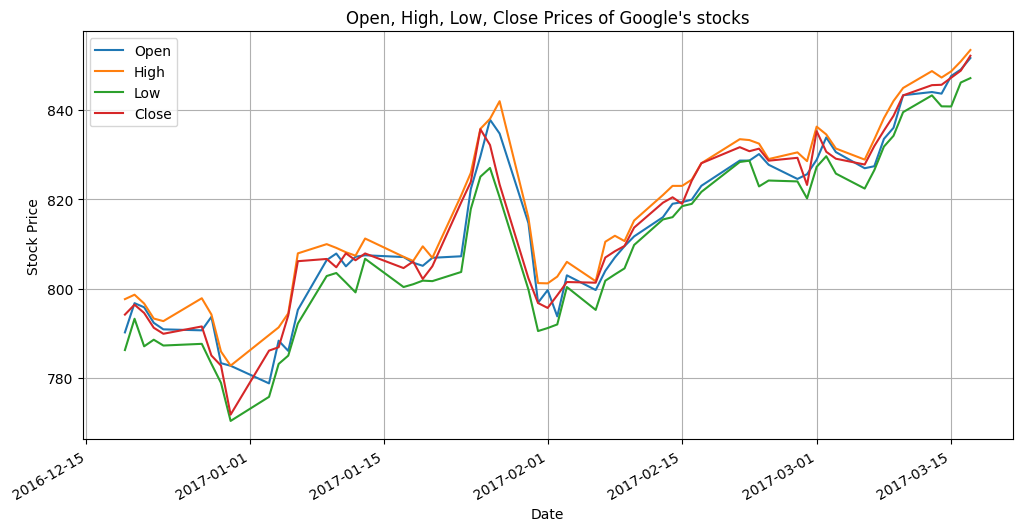

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
fig = df.plot(
    x="Date",
    y=["Open", "High", "Low", "Close"],
    figsize=(12, 6),
    title="Open, High, Low, Close Prices of Google's stocks"
)
fig.set_xlabel("Date")
fig.set_ylabel("Stock Price")
plt.grid(True)
plt.show()

In [45]:
# Select features, not date
data = df.drop("Date", axis=1)

In [46]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
target_data = scaled_data[:, 3]

def create_sequences(features, target, seq_len):
    X, y = [], []
    for i in range(seq_len, len(features)):
        X.append(features[i - seq_len : i])
        y.append(target[i])
    return np.array(X), np.array(y)


n_rows = len(scaled_data)
# With ~61 rows, seq_len=60 yields only ONE sequence and an empty train split.
# Use a shorter window when the CSV is short so you get enough sequences.
seq_len = min(60, max(5, n_rows // 2))
seq_len = min(seq_len, n_rows - 1)

X, y = create_sequences(scaled_data, target_data, seq_len=seq_len)
print(f"seq_len={seq_len}, rows={n_rows}, sequences={len(X)}")

seq_len=30, rows=61, sequences=31


In [47]:
X

array([[[0.15673043, 0.2107044 , 0.20678024, 0.27870496, 0.2312416 ],
        [0.24656614, 0.22472382, 0.29804489, 0.30635093, 0.11579351],
        [0.23392901, 0.19677141, 0.21760105, 0.28318798, 0.22464018],
        ...,
        [0.4924448 , 0.46813934, 0.38318136, 0.37982571, 1.        ],
        [0.24793943, 0.26154025, 0.26219092, 0.31095859, 0.58341969],
        [0.28667581, 0.26069066, 0.27092602, 0.29732258, 0.53728651]],

       [[0.24656614, 0.22472382, 0.29804489, 0.30635093, 0.11579351],
        [0.23392901, 0.19677141, 0.21760105, 0.28318798, 0.22464018],
        [0.18612623, 0.1492492 , 0.23689754, 0.24209223, 0.13268087],
        ...,
        [0.24793943, 0.26154025, 0.26219092, 0.31095859, 0.58341969],
        [0.28667581, 0.26069066, 0.27092602, 0.29732258, 0.53728651],
        [0.20590649, 0.28207285, 0.28148662, 0.33262797, 0.34634427]],

       [[0.23392901, 0.19677141, 0.21760105, 0.28318798, 0.22464018],
        [0.18612623, 0.1492492 , 0.23689754, 0.24209223, 0.1

In [48]:
n_seq = len(X)
if n_seq < 2:
    raise ValueError(
        f"Only {n_seq} sequence(s). Add more CSV rows or lower seq_len (currently tied to data size)."
    )

split = max(1, min(int(n_seq * 0.8), n_seq - 1))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"train={len(X_train)}, test={len(X_test)}, shape[1]={X_train.shape[1]}")

train=24, test=7, shape[1]=30


In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dropout, Dense

# Re-run this entire cell after edits — an old `model` in memory still has the previous input size.
n_features = X_train.shape[2]
seq_len = X_train.shape[1]

model = Sequential([
    Input(shape=(seq_len, n_features)),
    # First SimpleRNN layer — still needs return_sequences=True for the next RNN
    SimpleRNN(64, return_sequences=True),
    Dropout(0.2),

    # Second SimpleRNN layer
    # return_sequences=False (default) to output the final 1D summary
    SimpleRNN(64),
    Dropout(0.2),

    # Output layer
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 30, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.2889 - val_loss: 0.4379
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.6329 - val_loss: 0.1311
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.2602 - val_loss: 0.0038
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.2402 - val_loss: 0.0743
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.3405 - val_loss: 0.1752
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.3236 - val_loss: 0.1511
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.2876 - val_loss: 0.0745
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - loss: 0.3752 - val_loss: 0.0087
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.2290 - val_loss: 0.0175
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.2511 - val_loss: 0.0965
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.1717 - val_loss: 0.1984
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.2200 - val_loss: 0.2274
Epoch 13/50


In [51]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step


In [52]:
# Close was scaled with the same MinMaxScaler as other columns (index 3)
close_idx = 3
_close_lo = float(scaler.data_min_[close_idx])
_close_hi = float(scaler.data_max_[close_idx])


def inverse_close(normalized):
    a = np.asarray(normalized, dtype=np.float64).reshape(-1, 1)
    return a * (_close_hi - _close_lo) + _close_lo


predicted_values = inverse_close(y_pred)
actual_values = inverse_close(y_test)

In [53]:
# predicted_values / actual_values set in previous cell

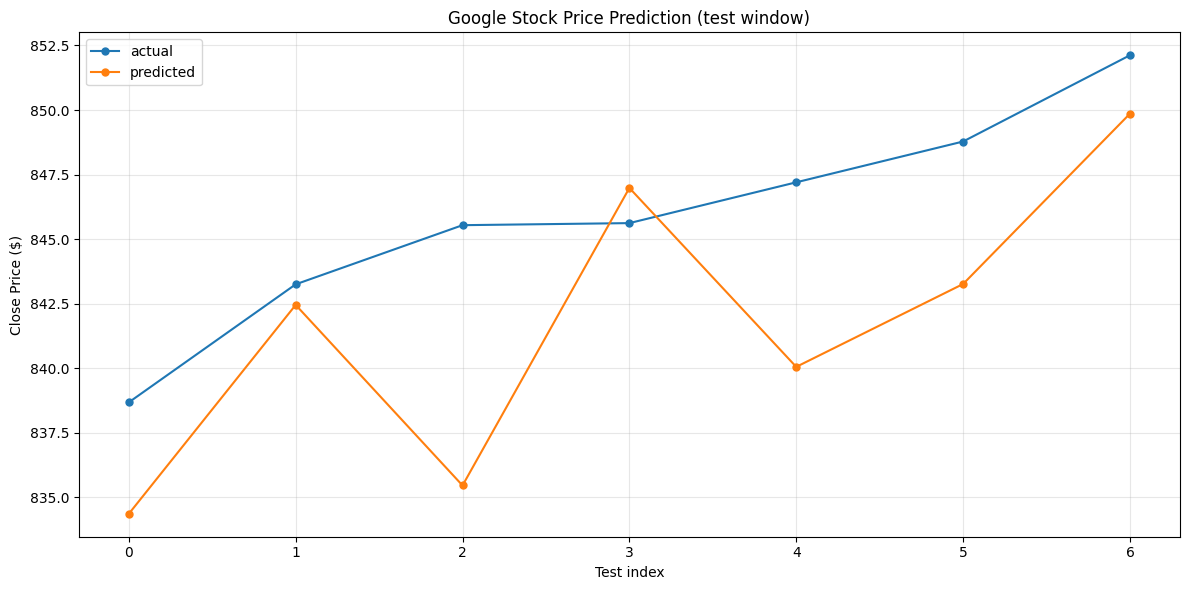

In [54]:
plt.figure(figsize=(12, 6))
x = np.arange(len(actual_values))
plot_kw = {"marker": "o", "markersize": 5} if len(actual_values) <= 50 else {}
plt.plot(x, actual_values, label="actual", **plot_kw)
plt.plot(x, predicted_values, label="predicted", **plot_kw)
plt.title("Google Stock Price Prediction (test window)")
plt.xlabel("Test index")
plt.ylabel("Close Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print(f"test points: {len(actual_values)}")

rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
mae = mean_absolute_error(actual_values, predicted_values)
print("RMSE:", rmse)
print("MAE:", mae)

if len(actual_values) >= 2:
    print("R2:", r2_score(actual_values, predicted_values))
else:
    print("R2: n/a (need at least 2 test points)")

test points: 7
RMSE: 5.469100036149537
MAE: 4.497673372512411
R2: -0.9381370544332395
